In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import scipy           # EKG verilerini elde etmek, analiz etmek ve düzeltmek
import numpy as np     # veri / sayı işleme 
import pandas as pd    # veri / sayı işleme
import matplotlib.pyplot as plt # grafik oluşturma


In [5]:
scipy.__version__

'1.15.3'

In [6]:
pip install pooch

Note: you may need to restart the kernel to use updated packages.


In [7]:
ekg=scipy.datasets.electrocardiogram()

In [8]:
ekg

array([-0.245, -0.215, -0.185, ..., -0.405, -0.395, -0.385])

In [9]:
ekg= pd.Series(ekg)

<Axes: >

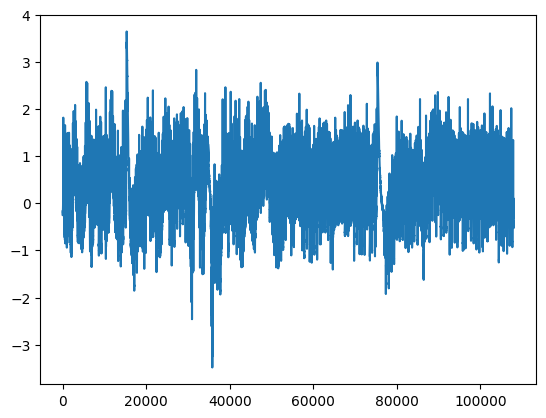

In [10]:
ekg.plot()

<Axes: >

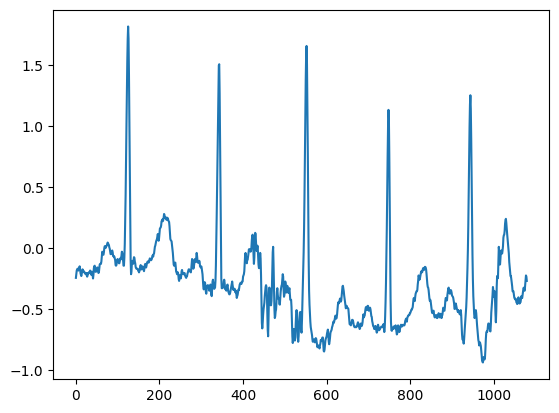

In [11]:
ekg[: 1080].plot()  #5 kalp atışı 

<Axes: >

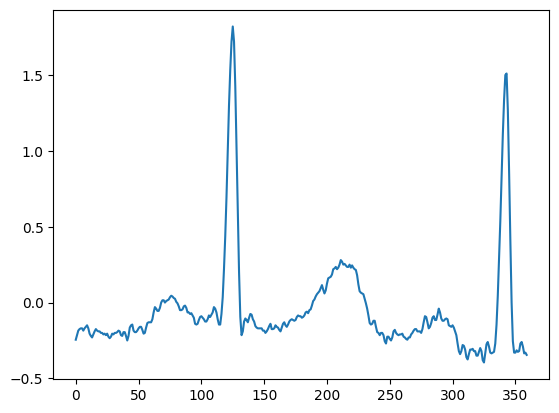

In [12]:
ekg[: 360].plot() # 1 kalp atışı ve diğerinin başlangıcı

Text(0.5, 1.0, '3 seconds of EKG data')

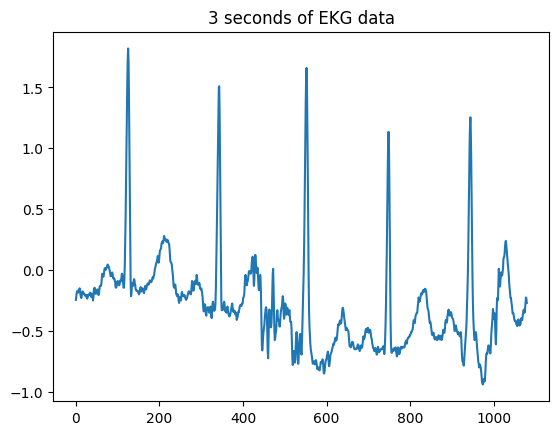

In [13]:
ekg[: 1080].plot()
plt.title("3 seconds of EKG data")

In [14]:
r_waves , metadata = scipy.signal.find_peaks(ekg[:1080], height= 1.0) # pik noktalarından kalbin R ritmi verdiği noktalar bulundu 1.0 da filtreleme yapıldı 

In [15]:
r_waves

array([125, 343, 552, 748, 944])

Text(0.5, 1.0, 'Three second EKG with labeled R waves')

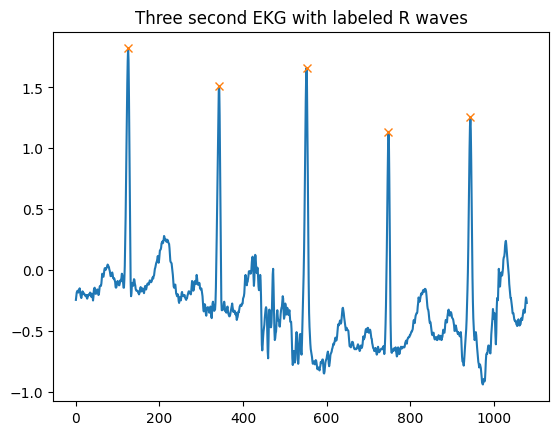

In [16]:
three_second_ekg=ekg[:1080]
three_second_ekg.plot()
plt.plot(r_waves , three_second_ekg[r_waves], "x")
plt.title("Three second EKG with labeled R waves")

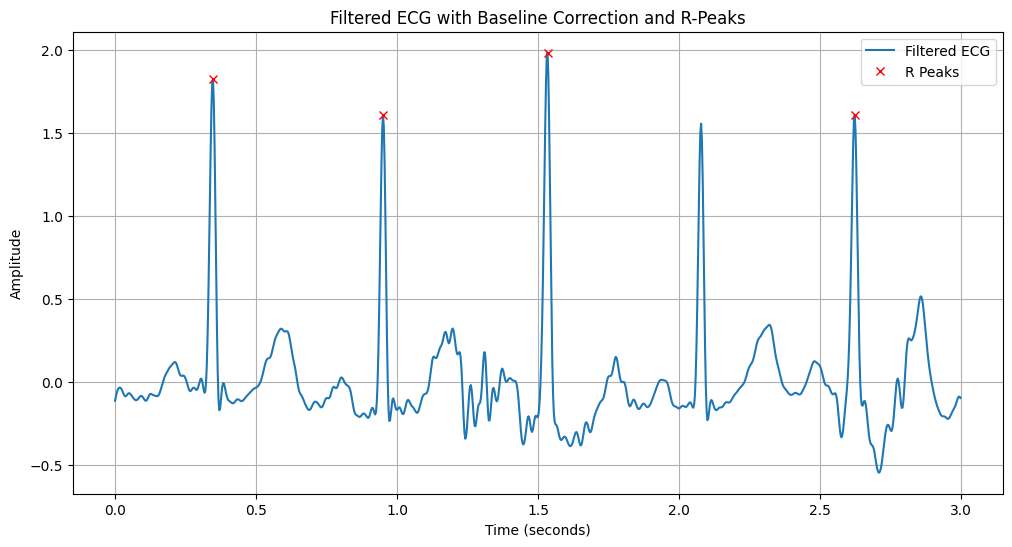

In [17]:
import scipy.signal as signal
import numpy as np
import matplotlib.pyplot as plt

# Örnekleme frekansı (scipy ECG dataset 360 Hz)
fs = 360  

# İlk 3 saniyeyi al
ekg_raw = ekg[:1080]

# Zaman ekseni oluştur (düzgün x ekseni için)
t = np.arange(len(ekg_raw)) / fs

# -----------------------------
# 1️⃣ Bandpass Filter (0.5 - 40 Hz)
# -----------------------------
lowcut = 0.5
highcut = 40

b, a = signal.butter(4, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
ekg_filtered = signal.filtfilt(b, a, ekg_raw)

# -----------------------------
# 2️⃣ R-peak detection (filtreli sinyalde)
# -----------------------------
r_waves_filtered, _ = signal.find_peaks(ekg_filtered, height=0.8, distance=200)

# -----------------------------
# 3️⃣ Grafik
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(t, ekg_filtered, label="Filtered ECG")
plt.plot(t[r_waves_filtered], ekg_filtered[r_waves_filtered], "rx", label="R Peaks")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Filtered ECG with Baseline Correction and R-Peaks")
plt.legend()
plt.grid()

plt.show()